In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Egypt_Water_Quality_ML_Dataset.csv")
df.head()

,test_id,company_id,governorate,region,source_type,year,month,season,pH,turbidity_NTU,...,chloride_mg_L,DO_mg_L,coliform_CFU_per_100mL,pH_compliant,turbidity_compliant,TDS_compliant,chlorine_compliant,nitrate_compliant,coliform_compliant,potable
0,1,1,Cairo,Greater Cairo,Nile River,2021,11,Autumn,7.86,0.77,...,35,10.0,1,1,1,1,1,1,0,0
1,2,1,Cairo,Greater Cairo,Nile River,2020,3,Spring,7.82,0.49,...,36,10.0,0,1,1,1,1,1,1,1
2,3,1,Cairo,Greater Cairo,Nile River,2023,6,Summer,7.84,0.31,...,56,10.0,1,1,1,1,1,1,0,0
3,4,1,Cairo,Greater Cairo,Nile River,2021,1,Winter,7.79,0.38,...,37,10.0,0,1,1,1,1,1,1,1
4,5,1,Cairo,Greater Cairo,Nile River,2022,12,Winter,7.90,0.48,...,29,10.0,0,1,1,1,1,1,1,1


In [3]:
df.shape

(1000, 30)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   test_id                 1000 non-null   int64  
 1   company_id              1000 non-null   int64  
 2   governorate             1000 non-null   object 
 3   region                  1000 non-null   object 
 4   source_type             1000 non-null   object 
 5   year                    1000 non-null   int64  
 6   month                   1000 non-null   int64  
 7   season                  1000 non-null   object 
 8   pH                      1000 non-null   float64
 9   turbidity_NTU           1000 non-null   float64
 10  TDS_mg_L                1000 non-null   int64  
 11  chlorine_mg_L           1000 non-null   float64
 12  EC_uS_cm                1000 non-null   int64  
 13  nitrate_mg_L            1000 non-null   float64
 14  nitrite_mg_L            1000 non-null   f

In [5]:
df['potable'].value_counts()

potable
0    740
1    260
Name: count, dtype: int64

In [6]:
df.describe()

,test_id,company_id,year,month,pH,turbidity_NTU,TDS_mg_L,chlorine_mg_L,EC_uS_cm,nitrate_mg_L,...,chloride_mg_L,DO_mg_L,coliform_CFU_per_100mL,pH_compliant,turbidity_compliant,TDS_compliant,chlorine_compliant,nitrate_compliant,coliform_compliant,potable
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.00000,1000.0,1000.000000,1000.0,1000.000000,1000.0,1000.0,1000.0,1000.000000,1000.000000
mean,500.500000,10.823000,2021.657000,6.533000,7.551410,1.565080,368.210000,0.534650,608.301000,5.82578,...,68.20300,10.0,0.551000,1.0,0.358000,1.0,1.0,1.0,0.674000,0.260000
std,288.819436,6.669044,1.048069,3.459607,0.218186,1.029868,96.325316,0.133449,130.603544,3.53971,...,33.93189,0.0,0.995183,0.0,0.479652,0.0,0.0,0.0,0.468982,0.438854
min,1.000000,1.000000,2020.000000,1.000000,6.780000,0.050000,211.000000,0.210000,382.000000,0.10000,...,15.00000,10.0,0.000000,1.0,0.000000,1.0,1.0,1.0,0.000000,0.000000
25%,250.750000,5.000000,2021.000000,4.000000,7.410000,0.750000,298.000000,0.440000,516.000000,3.22000,...,45.00000,10.0,0.000000,1.0,0.000000,1.0,1.0,1.0,0.000000,0.000000
50%,500.500000,10.000000,2022.000000,7.000000,7.570000,1.375000,337.000000,0.520000,572.000000,5.07500,...,57.00000,10.0,0.000000,1.0,0.000000,1.0,1.0,1.0,1.000000,0.000000
75%,750.250000,16.000000,2023.000000,9.000000,7.720000,2.190000,419.250000,0.620000,672.000000,7.77000,...,84.00000,10.0,1.000000,1.0,1.000000,1.0,1.0,1.0,1.000000,1.000000
max,1000.000000,23.000000,2023.000000,12.000000,8.100000,5.870000,752.000000,0.910000,1356.000000,22.36000,...,235.00000,10.0,6.000000,1.0,1.000000,1.0,1.0,1.0,1.000000,1.000000


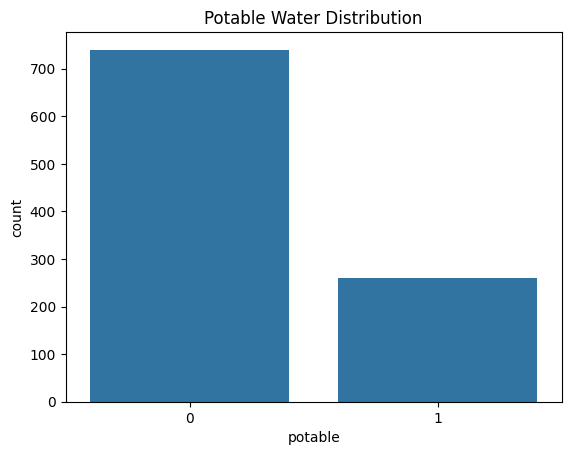

In [7]:
sns.countplot(x='potable', data=df)
plt.title("Potable Water Distribution")
plt.show()

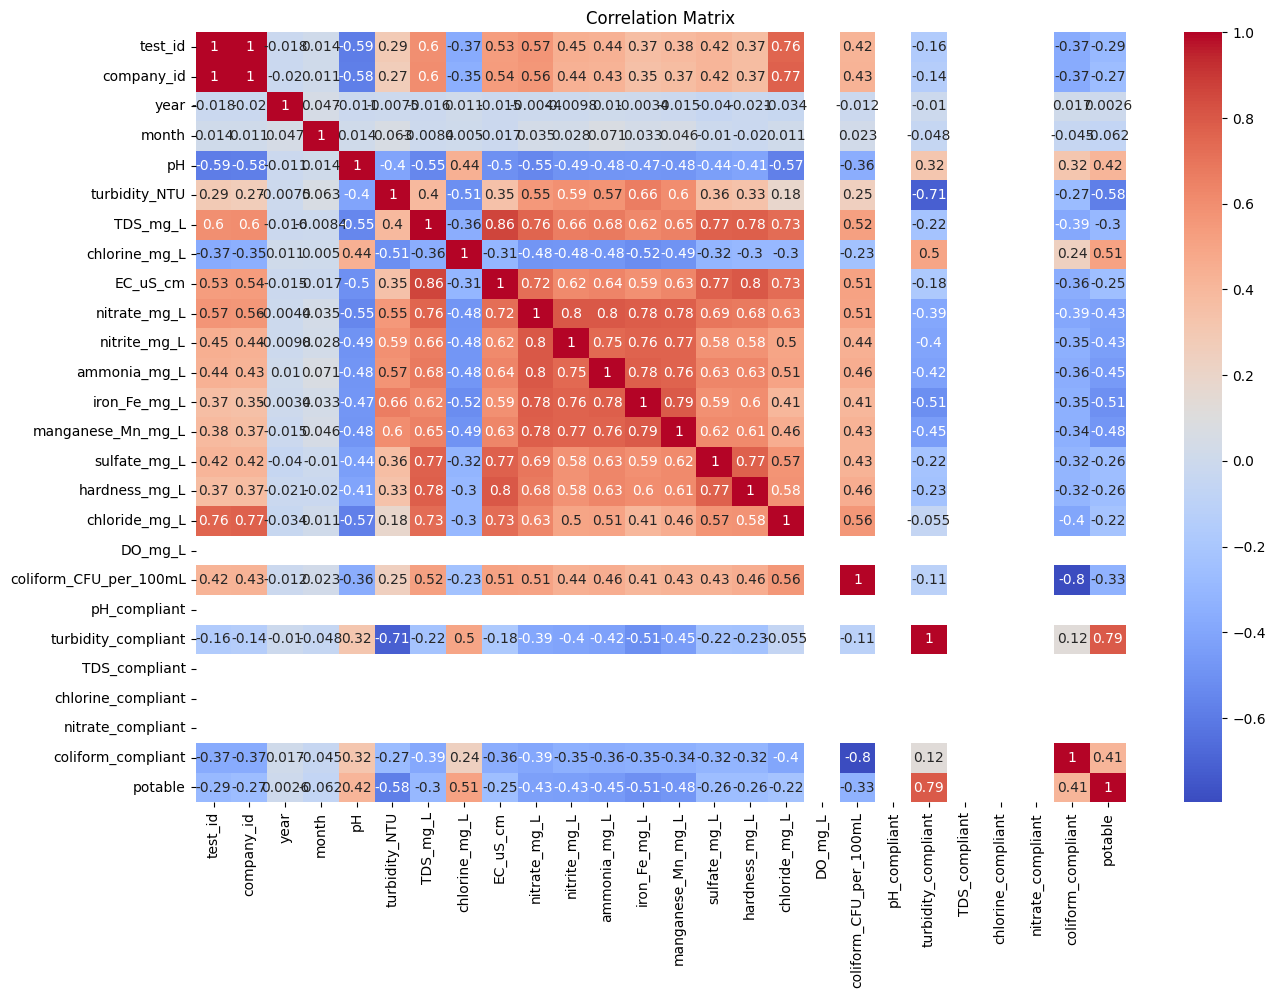

In [8]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [9]:
corr_target = df.corr(numeric_only=True)['potable'].sort_values(ascending=False)

print(corr_target)

potable                   1.000000
turbidity_compliant       0.793774
chlorine_mg_L             0.512955
pH                        0.415692
coliform_compliant        0.412240
year                      0.002568
month                    -0.062357
chloride_mg_L            -0.223160
EC_uS_cm                 -0.250954
hardness_mg_L            -0.256704
sulfate_mg_L             -0.261581
company_id               -0.268821
test_id                  -0.288653
TDS_mg_L                 -0.296459
coliform_CFU_per_100mL   -0.328350
nitrate_mg_L             -0.430195
nitrite_mg_L             -0.432291
ammonia_mg_L             -0.454992
manganese_Mn_mg_L        -0.479836
iron_Fe_mg_L             -0.507482
turbidity_NTU            -0.584353
DO_mg_L                        NaN
pH_compliant                   NaN
TDS_compliant                  NaN
chlorine_compliant             NaN
nitrate_compliant              NaN
Name: potable, dtype: float64


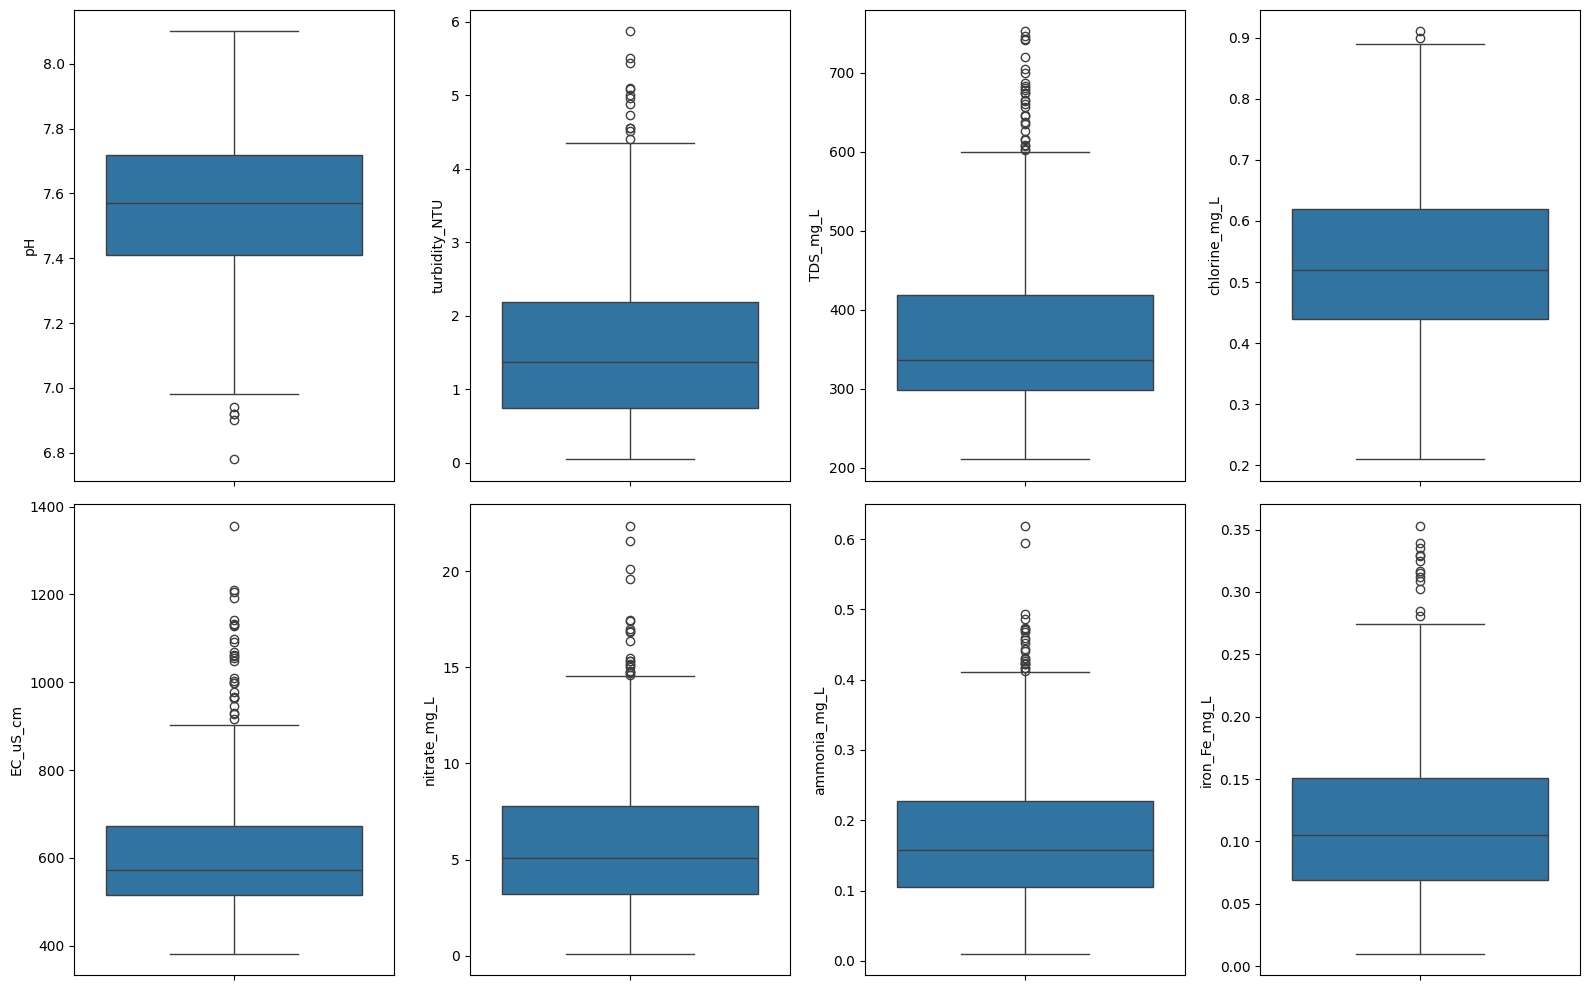

In [10]:
features = [
    'pH',
    'turbidity_NTU',
    'TDS_mg_L',
    'chlorine_mg_L',
    'EC_uS_cm',
    'nitrate_mg_L',
    'ammonia_mg_L',
    'iron_Fe_mg_L'
]

plt.figure(figsize=(16,10))

for i, col in enumerate(features, 1):
    plt.subplot(2,4,i)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

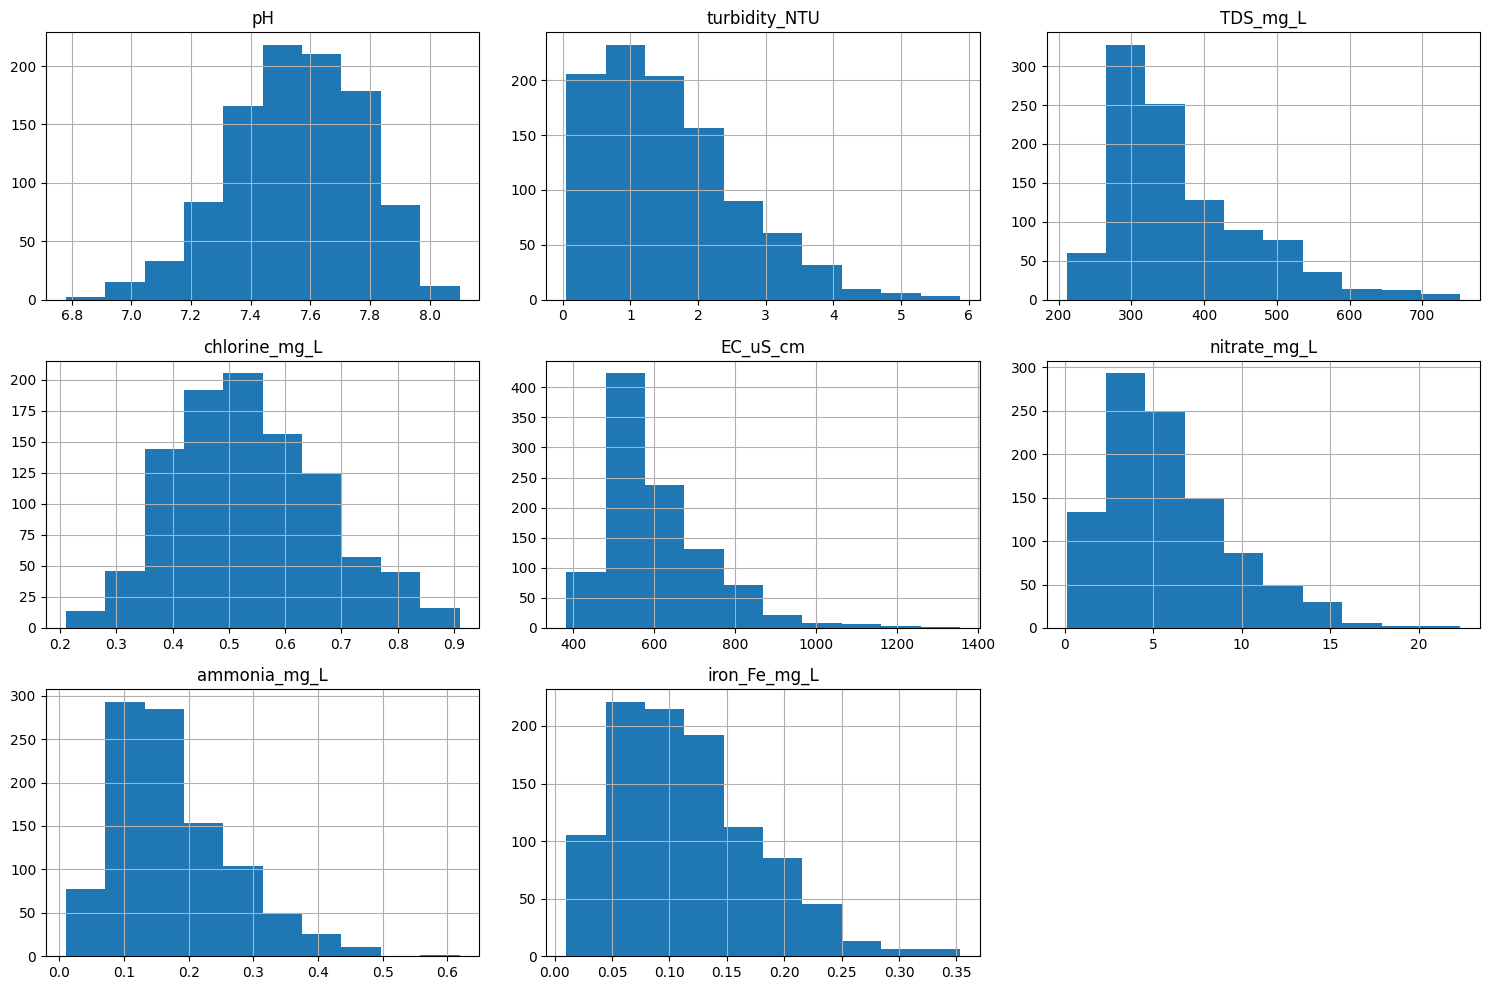

In [11]:
df[features].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

In [12]:
columns_to_drop = [
    'test_id',
    'company_id',
    'governorate',
    'region',
    'source_type',
    'season',
    'year',
    'month',
    'DO_mg_L',
    'pH_compliant',
    'turbidity_compliant',
    'TDS_compliant',
    'chlorine_compliant',
    'nitrate_compliant',
    'coliform_compliant'
]

df = df.drop(columns=columns_to_drop)

In [13]:
df.head()

,pH,turbidity_NTU,TDS_mg_L,chlorine_mg_L,EC_uS_cm,nitrate_mg_L,nitrite_mg_L,ammonia_mg_L,iron_Fe_mg_L,manganese_Mn_mg_L,sulfate_mg_L,hardness_mg_L,chloride_mg_L,coliform_CFU_per_100mL,potable
0,7.86,0.77,275,0.67,450,1.90,0.015,0.062,0.056,0.019,43,140,35,1,0
1,7.82,0.49,326,0.67,509,3.35,0.005,0.124,0.067,0.013,52,155,36,0,1
2,7.84,0.31,253,0.58,552,3.27,0.021,0.071,0.085,0.028,47,160,56,1,0
3,7.79,0.38,255,0.60,562,2.28,0.014,0.082,0.057,0.018,42,169,37,0,1
4,7.90,0.48,268,0.67,563,2.35,0.017,0.087,0.097,0.011,40,147,29,0,1


In [14]:
X = df.drop('potable', axis=1)
y = df['potable']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00        52

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix:

[[148   0]
 [  0  52]]


In [19]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                   Feature  Importance
1            turbidity_NTU    0.358216
13  coliform_CFU_per_100mL    0.141981
8             iron_Fe_mg_L    0.090528
9        manganese_Mn_mg_L    0.075538
5             nitrate_mg_L    0.053690
3            chlorine_mg_L    0.051818
7             ammonia_mg_L    0.049688
0                       pH    0.046602
6             nitrite_mg_L    0.033345
12           chloride_mg_L    0.024018
4                 EC_uS_cm    0.022147
11           hardness_mg_L    0.019609
2                 TDS_mg_L    0.016449
10            sulfate_mg_L    0.016372


In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print(scores)
print("Average Accuracy:", scores.mean())

[1.    0.995 0.99  0.925 1.   ]
Average Accuracy: 0.982


In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       148
           1       0.98      0.92      0.95        52

    accuracy                           0.97       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.98      0.97      0.97       200



c:\Users\Tarek00\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
import joblib

joblib.dump(model, "water_quality_model.pkl")

['water_quality_model.pkl']

In [23]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

In [24]:
print(model.classes_)

[0 1]


In [25]:
df.groupby('potable').mean()

,pH,turbidity_NTU,TDS_mg_L,chlorine_mg_L,EC_uS_cm,nitrate_mg_L,nitrite_mg_L,ammonia_mg_L,iron_Fe_mg_L,manganese_Mn_mg_L,sulfate_mg_L,hardness_mg_L,chloride_mg_L,coliform_CFU_per_100mL
potable,,,,,,,,,,,,,,
0,7.497676,1.921622,385.128378,0.494095,627.718919,6.727946,0.026880,0.200897,0.133462,0.043473,58.209459,181.159459,72.689189,0.744595
1,7.704346,0.550308,320.057692,0.650077,553.034615,3.258077,0.014077,0.103577,0.062996,0.021362,47.211538,152.076923,55.434615,0.000000
